In [7]:
import requests
import pandas as pd
import refet
from geopy.geocoders import Nominatim
import time

# ── FONCTION NASA POWER ──────────────────────────────────────
def get_nasa_power(lat, lon, start, end):
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "parameters" : "T2M_MAX,T2M_MIN,RH2M,WS2M,ALLSKY_SFC_SW_DWN,PRECTOTCORR",
        "community"  : "AG",
        "longitude"  : lon,
        "latitude"   : lat,
        "start"      : start,
        "end"        : end,
        "format"     : "JSON"
    }
    response = requests.get(url, params=params, timeout=60)
    data     = response.json()
    meteo    = data["properties"]["parameter"]
    df = pd.DataFrame(meteo)
    df.index = pd.to_datetime(df.index, format="%Y%m%d")
    df.index.name = "date"
    df = df.rename(columns={
        "T2M_MAX"           : "temp_max",
        "T2M_MIN"           : "temp_min",
        "RH2M"              : "humidite",
        "WS2M"              : "vent",
        "ALLSKY_SFC_SW_DWN" : "rayonnement",
        "PRECTOTCORR"       : "precipitations"
    })
    df = df.replace(-999, float("nan"))
    df = df.interpolate(method="linear")
    return df

# ── FONCTION ET0 ─────────────────────────────────────────────
def calculer_ET0(row):
    tdew = row["temp_min"] - ((100 - row["humidite"]) / 5)
    et0  = refet.Daily(
        tmax   = row["temp_max"],
        tmin   = row["temp_min"],
        tdew   = tdew,
        rs     = row["rayonnement"],
        uz     = row["vent"],
        zw     = 2,
        elev   = 5,
        lat    = 16.01,
        doy    = row["doy"],
        method = "asce"
    ).eto()
    return float(et0[0])

# ── COORDONNEES VIA GEOPY ────────────────────────────────────
geolocator  = Nominatim(user_agent="memoire_irrigation")
villes_noms = ["Saint-Louis, Senegal", "Dagana, Senegal",
               "Podor, Senegal", "Matam, Senegal"]
villes = {}

for nom in villes_noms:
    location  = geolocator.geocode(nom)
    nom_court = nom.split(",")[0]
    villes[nom_court] = {
        "lat" : location.latitude,
        "lon" : location.longitude
    }
    print(f"{nom_court} → lat: {location.latitude:.4f}, lon: {location.longitude:.4f}")
    time.sleep(1)

# ── TELECHARGEMENT ET CALCUL POUR CHAQUE VILLE ───────────────
resultats = {}

for ville, coords in villes.items():
    print(f"\nTelechargement {ville}...")
    
    df_ville = get_nasa_power(
        lat   = coords["lat"],
        lon   = coords["lon"],
        start = "20210101",
        end   = "20231231"
    )
    
    df_ville["doy"] = df_ville.index.dayofyear
    df_ville["ET0"] = df_ville.apply(calculer_ET0, axis=1)
    df_ville["ETc"] = df_ville["ET0"] * 1.15
    df_ville["besoin_irrigation"] = (
        df_ville["ETc"] - df_ville["precipitations"]
    ).apply(lambda x: round(x, 2) if x > 0 else 0)
    
    resultats[ville] = df_ville
    print(f"{ville} OK - ET0 moy: {df_ville['ET0'].mean():.2f} mm/jour")

print("\nToutes les villes traitees !")

Saint-Louis → lat: 16.0280, lon: -16.5049
Dagana → lat: 16.5165, lon: -15.5068
Podor → lat: 16.6527, lon: -14.9587
Matam → lat: 15.2681, lon: -13.6992

Telechargement Saint-Louis...
Saint-Louis OK - ET0 moy: 7.35 mm/jour

Telechargement Dagana...
Dagana OK - ET0 moy: 8.32 mm/jour

Telechargement Podor...
Podor OK - ET0 moy: 8.31 mm/jour

Telechargement Matam...
Matam OK - ET0 moy: 7.57 mm/jour

Toutes les villes traitees !


Sauvegarde : donnees_saint_louis_2021_2023.csv
Sauvegarde : donnees_dagana_2021_2023.csv
Sauvegarde : donnees_podor_2021_2023.csv
Sauvegarde : donnees_matam_2021_2023.csv


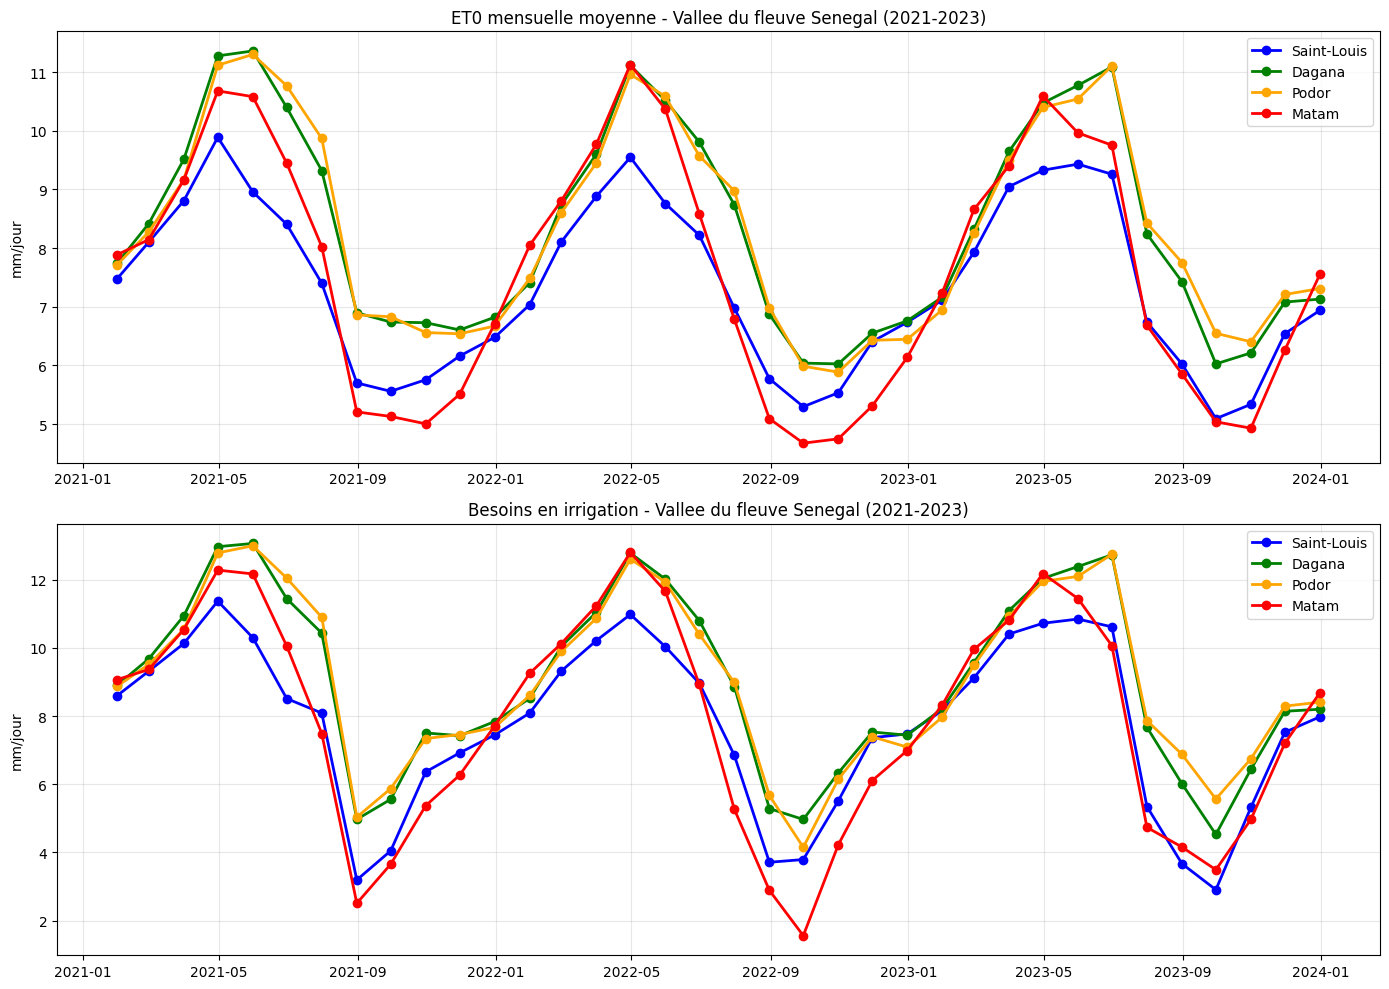


=== TABLEAU RECAPITULATIF ===
Ville              ET0 moy    ETc moy   Besoin irrig  Pluie moy
-----------------------------------------------------------------
Saint-Louis          7.35      8.45          7.74      1.37
Dagana               8.32      9.57          8.98      0.98
Podor                8.31      9.56          8.98      1.03
Matam                7.57      8.71          7.86      2.01


In [8]:
import matplotlib.pyplot as plt

# ── SAUVEGARDER CHAQUE VILLE EN CSV ──────────────────────────
for ville, df_ville in resultats.items():
    nom_fichier = f"donnees_{ville.lower().replace('-', '_')}_2021_2023.csv"
    df_ville.to_csv(nom_fichier)
    print(f"Sauvegarde : {nom_fichier}")

# ── COMPARAISON ET0 ENTRE LES 4 VILLES ───────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Graphique 1 - ET0 comparatif
couleurs = ["blue", "green", "orange", "red"]
for (ville, df_ville), couleur in zip(resultats.items(), couleurs):
    # Moyennes mensuelles pour lisibilite
    et0_mensuel = df_ville["ET0"].resample("ME").mean()
    axes[0].plot(et0_mensuel.index, et0_mensuel.values,
                 label=ville, color=couleur, linewidth=2, marker="o")

axes[0].set_title("ET0 mensuelle moyenne - Vallee du fleuve Senegal (2021-2023)")
axes[0].set_ylabel("mm/jour")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 - Besoin irrigation comparatif
for (ville, df_ville), couleur in zip(resultats.items(), couleurs):
    besoin_mensuel = df_ville["besoin_irrigation"].resample("ME").mean()
    axes[1].plot(besoin_mensuel.index, besoin_mensuel.values,
                 label=ville, color=couleur, linewidth=2, marker="o")

axes[1].set_title("Besoins en irrigation - Vallee du fleuve Senegal (2021-2023)")
axes[1].set_ylabel("mm/jour")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("comparaison_villes_2021_2023.png", dpi=150)
plt.show()

# ── TABLEAU RECAPITULATIF ─────────────────────────────────────
print("\n=== TABLEAU RECAPITULATIF ===")
print(f"{'Ville':<15} {'ET0 moy':>10} {'ETc moy':>10} {'Besoin irrig':>14} {'Pluie moy':>10}")
print("-" * 65)
for ville, df_ville in resultats.items():
    print(f"{ville:<15}"
          f"{df_ville['ET0'].mean():>10.2f}"
          f"{df_ville['ETc'].mean():>10.2f}"
          f"{df_ville['besoin_irrigation'].mean():>14.2f}"
          f"{df_ville['precipitations'].mean():>10.2f}")

In [9]:
import ee

# Authentification - va ouvrir ton navigateur Google
ee.Authenticate()

# Initialise avec ton projet
ee.Initialize(project="memoire-irrigation-senegal")

print("GEE connecte !")

GEE connecte !


In [16]:
import ee
import geemap
import pandas as pd

ee.Initialize(project="memoire-irrigation-senegal")

# Zones agricoles des 4 villes
zones = {
    "Dagana"      : ee.Geometry.Rectangle([-15.55, 15.50, -15.45, 15.60]),
    "Saint-Louis" : ee.Geometry.Rectangle([-16.55, 15.95, -16.45, 16.05]),
    "Podor"       : ee.Geometry.Rectangle([-15.00, 16.60, -14.90, 16.70]),
    "Matam"       : ee.Geometry.Rectangle([-13.30, 15.20, -13.20, 15.30])
}

def calculer_indices(image):
    ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")
    ndwi = image.normalizedDifference(["B8", "B11"]).rename("NDWI")
    savi = (image.expression(
        "1.5 * (NIR - Rouge) / (NIR + Rouge + 0.5)",
        {"NIR": image.select("B8"), "Rouge": image.select("B4")}
    )).rename("SAVI")
    return image.addBands([ndvi, ndwi, savi])

df_satellites = {}

for ville, zone in zones.items():
    print(f"Extraction GEE - {ville}...")

    collection = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterDate("2021-01-01", "2023-12-31")
        .filterBounds(zone)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 10))
        .map(calculer_indices))

    print(f"  Images : {collection.size().getInfo()}")

    def extraire_valeurs(image):
        date    = ee.Date(image.get("system:time_start")).format("YYYY-MM-dd")
        valeurs = image.select(["NDVI", "NDWI", "SAVI"]).reduceRegion(
            reducer  = ee.Reducer.mean(),
            geometry = zone,
            scale    = 10
        )
        return ee.Feature(None, valeurs.set("date", date))

    features = collection.map(extraire_valeurs)
    df_sat   = pd.DataFrame([
        f["properties"] for f in features.getInfo()["features"]
    ])
    df_sat["date"] = pd.to_datetime(df_sat["date"])
    df_sat = df_sat.sort_values("date").set_index("date")
    df_satellites[ville] = df_sat
    print(f"  OK - {df_sat.shape[0]} images")

print("\nExtraction GEE terminee !")

Extraction GEE - Dagana...
  Images : 186
  OK - 186 images
Extraction GEE - Saint-Louis...
  Images : 85
  OK - 85 images
Extraction GEE - Podor...
  Images : 202
  OK - 202 images
Extraction GEE - Matam...
  Images : 370
  OK - 370 images

Extraction GEE terminee !


In [18]:
def classifier_stress(ndwi):
    if ndwi >= 0.0   : return 0
    elif ndwi >= -0.2: return 1
    else             : return 2

dfs_finaux = {}

for ville in zones.keys():
    print(f"Fusion {ville}...")
    df_climat = resultats[ville].copy()

    # Supprimer les dates en double dans les donnees satellites
    df_sat = df_satellites[ville].copy()
    df_sat = df_sat[~df_sat.index.duplicated(keep="first")]

    # Interpolation journaliere
    df_sat_daily = df_sat.reindex(df_climat.index)
    df_sat_daily = df_sat_daily.interpolate(method="time")
    df_sat_daily = df_sat_daily.bfill().ffill()

    # Fusion
    df_ville = pd.concat([df_climat, df_sat_daily], axis=1)
    df_ville["stress_hydrique"] = df_ville["NDWI"].apply(classifier_stress)
    df_ville["ville"]           = ville
    dfs_finaux[ville]           = df_ville

    print(f"  {ville} OK - {df_ville.shape} - NaN: {df_ville.isnull().sum().sum()}")

df_complet = pd.concat(dfs_finaux.values())
df_complet.to_csv("BASE_COMPLETE_4VILLES_2021_2023.csv")

print(f"\nBase complete : {df_complet.shape}")
print(f"\nDistribution stress :")
print(df_complet.groupby(["ville", "stress_hydrique"])
      .size().unstack()
      .rename(columns={0:"Faible", 1:"Modere", 2:"Severe"}))

Fusion Dagana...
  Dagana OK - (1095, 15) - NaN: 0
Fusion Saint-Louis...
  Saint-Louis OK - (1095, 15) - NaN: 0
Fusion Podor...
  Podor OK - (1095, 15) - NaN: 0
Fusion Matam...
  Matam OK - (1095, 15) - NaN: 0

Base complete : (4380, 15)

Distribution stress :
stress_hydrique  Faible  Modere  Severe
ville                                  
Dagana             91.0   465.0   539.0
Matam             169.0   875.0    51.0
Podor             171.0   924.0     NaN
Saint-Louis       508.0   585.0     2.0


In [19]:
# Remplacer NaN par 0 dans le tableau de distribution
print(df_complet.groupby(["ville", "stress_hydrique"])
      .size().unstack(fill_value=0)
      .rename(columns={0:"Faible", 1:"Modere", 2:"Severe"}))

stress_hydrique  Faible  Modere  Severe
ville                                  
Dagana               91     465     539
Matam               169     875      51
Podor               171     924       0
Saint-Louis         508     585       2
